In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import optuna
from xgboost import XGBRegressor

c:\Users\jaime\Desktop\P7-regression-grupo4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
df = pd.read_csv("../csv/clean_cars2.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192529 entries, 0 to 192528
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   brand          192529 non-null  object 
 1   model          192529 non-null  object 
 2   model_year     192529 non-null  int64  
 3   milage         192529 non-null  int64  
 4   fuel_type      187276 non-null  object 
 5   transmission   192529 non-null  object 
 6   ext_col        192529 non-null  object 
 7   int_col        192529 non-null  object 
 8   accident       192529 non-null  int64  
 9   clean_title    192529 non-null  int64  
 10  price          192529 non-null  int64  
 11  brand_id       192529 non-null  int64  
 12  engine_liters  192529 non-null  float64
 13  cylinders      192529 non-null  int64  
 14  turbo          192529 non-null  int64  
 15  horsepower     192529 non-null  int64  
 16  fuel_diesel    192529 non-null  int64  
 17  fuel_electric  192529 non-nul


#### Preparamos x e y

In [10]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)

#### Métricas de evaluación

In [11]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Random Forest Regressor

In [12]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=19,
    min_samples_leaf=9, # ⬇️ reduce ruido
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_rf_train = np.expm1(rf.predict(x_train))
y_pred_rf_test  = np.expm1(rf.predict(x_test))


#### Gradient Boosting

In [13]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))


####  HGB

In [14]:
hgb = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.05,
    max_iter=400,
    l2_regularization=0.1,
    random_state=42
)

hgb.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

#### XGBoost

In [15]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb.fit(x_train, y_train)

# Predicciones
y_pred_xgb = np.expm1(xgb.predict(x_test))
y_test_real = np.expm1(y_test)

#### Elección del modelo


##### RMSE
##### Random Forest / GBR

In [16]:
importances = pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

importances.head(5)

milage           0.669461
model_year       0.182790
horsepower       0.073739
engine_liters    0.035358
brand_id         0.022836
dtype: float64

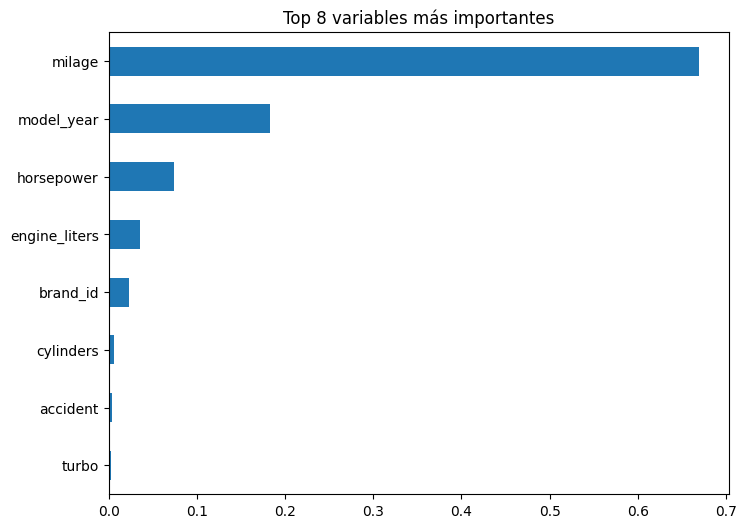

In [17]:
importances.head(8).plot(kind='barh', figsize=(8,6))
plt.title('Top 8 variables más importantes')
plt.gca().invert_yaxis()
plt.show()

#### Análisis de errores

##### Predicción vs real

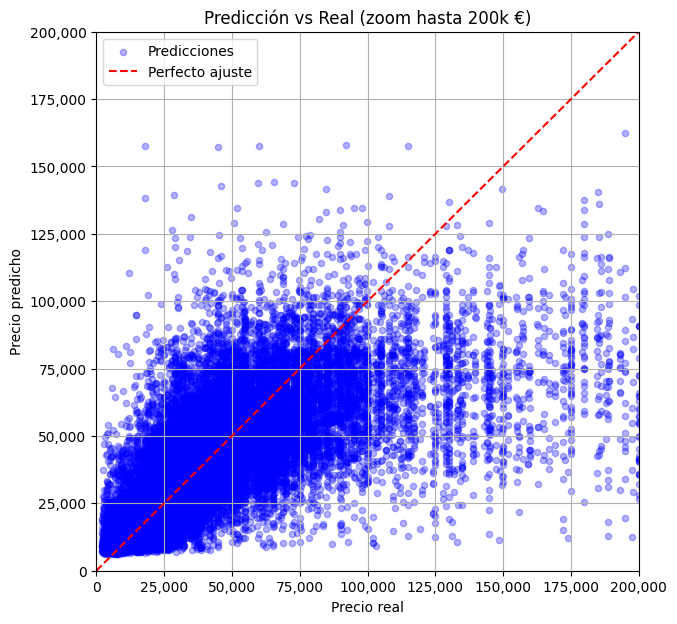

In [18]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, np.expm1(gbr.predict(x_test)),
            alpha=0.3, s=20, color='blue', label='Predicciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.legend()
plt.show()


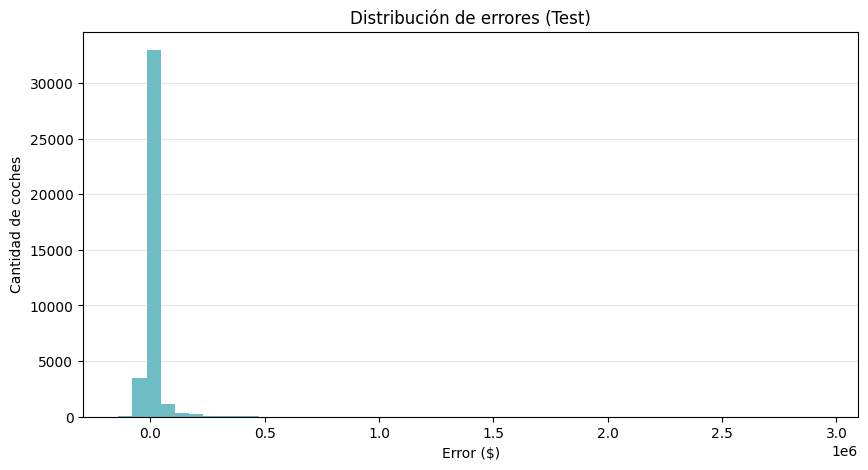

In [19]:
# Predicciones de test
y_pred_gbr_test = np.expm1(gbr.predict(x_test))

# Errores
errors = y_test_real - y_pred_gbr_test

# Histograma
plt.figure(figsize=(10,5))
plt.hist(errors, bins=50, color='#31A2AC', alpha=0.7)
plt.title('Distribución de errores (Test)')
plt.xlabel('Error ($)')
plt.ylabel('Cantidad de coches')
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Validación cruzada

In [20]:
def objective_rf(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)

    rmse = np.sqrt(
        -cross_val_score(
            model,
            x_train,
            y_train,
            cv=5,
            scoring='neg_mean_squared_error'
        ).mean()
    )

    return rmse

In [21]:
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=3)
study_rf.best_params

[I 2026-01-29 14:29:23,267] A new study created in memory with name: no-name-1c1c8104-a5c5-40bc-a60d-4fdb2f44e1f8
[W 2026-01-29 14:29:38,725] Trial 0 failed with parameters: {'n_estimators': 329, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 20} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\jaime\Desktop\P7-regression-grupo4\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\jaime\AppData\Local\Temp\ipykernel_33484\644681491.py", line 15, in objective_rf
    -cross_val_score(
     ^^^^^^^^^^^^^^^^
  File "c:\Users\jaime\Desktop\P7-regression-grupo4\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jaime\Desktop\P7-regression-grupo4\.venv\Lib\site-packages\sklearn\model_selection\_validation.

KeyboardInterrupt: 

In [ ]:
def objective_xgb(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 10.0),
        'objective': 'reg:squarederror',
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**params)

    rmse = np.sqrt(
        -cross_val_score(
            model,
            x_train,
            y_train,
            cv=3,
            scoring='neg_mean_squared_error'
        ).mean()
    )

    return rmse

In [ ]:
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=30)
study_xgb.best_params

[I 2026-01-29 11:35:51,810] A new study created in memory with name: no-name-d9e1da36-03f8-4569-ab78-296438d12cca
[I 2026-01-29 11:36:10,503] Trial 0 finished with value: 0.447502811773705 and parameters: {'n_estimators': 207, 'max_depth': 10, 'learning_rate': 0.03278303237419242, 'subsample': 0.7001286918770118, 'colsample_bytree': 0.6196827778586617, 'min_child_weight': 17, 'reg_alpha': 0.22445835522516122, 'reg_lambda': 4.7930848029739686}. Best is trial 0 with value: 0.447502811773705.
[I 2026-01-29 11:36:41,228] Trial 1 finished with value: 0.4510246054322667 and parameters: {'n_estimators': 600, 'max_depth': 9, 'learning_rate': 0.06908899405381433, 'subsample': 0.6916608393397885, 'colsample_bytree': 0.6376025602695907, 'min_child_weight': 5, 'reg_alpha': 0.15624609869389883, 'reg_lambda': 5.843404196528483}. Best is trial 0 with value: 0.447502811773705.
[I 2026-01-29 11:37:01,627] Trial 2 finished with value: 0.44821469387609303 and parameters: {'n_estimators': 343, 'max_depth'

{'n_estimators': 311,
 'max_depth': 9,
 'learning_rate': 0.039991087393241476,
 'subsample': 0.6433926159857134,
 'colsample_bytree': 0.6375130349766205,
 'min_child_weight': 3,
 'reg_alpha': 0.8516468811578269,
 'reg_lambda': 8.905645468783394}

#### Ajuste de hiperparametros

In [ ]:
###param_grid = {
   ### 'n_estimators': [100, 200, 300],
    ##'max_depth': [3, 5],
    ##'learning_rate': [0.03, 0.05]
##}

##grid = GridSearchCV(
  ##  RandomForestRegressor(random_state=42),
    ##param_grid,
   ##cv=3,
   ## scoring='neg_mean_squared_error',
   ## n_jobs=-1
##)

##grid.fit(x_train, y_train)
##grid.best_params_

In [22]:
# Revertir y reales
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

y_pred_rf_train  = np.expm1(rf.predict(x_train))
y_pred_rf_test   = np.expm1(rf.predict(x_test))

y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

y_pred_xgb_train = np.expm1(xgb.predict(x_train))
y_pred_xgb_test  = np.expm1(xgb.predict(x_test))

In [23]:
# MAE
mae_train_gbr = mean_absolute_error(y_train_real, y_pred_gbr_train)
mae_test_gbr  = mean_absolute_error(y_test_real, y_pred_gbr_test)

mae_train_rf = mean_absolute_error(y_train_real, y_pred_rf_train)
mae_test_rf  = mean_absolute_error(y_test_real, y_pred_rf_test)

mae_train_hgb = mean_absolute_error(y_train_real, y_pred_hgb_train)
mae_test_hgb  = mean_absolute_error(y_test_real, y_pred_hgb_test)

mae_train_xgb = mean_absolute_error(y_train_real, y_pred_xgb_train)
mae_test_xgb  = mean_absolute_error(y_test_real, y_pred_xgb_test)

In [24]:
overfit_gbr = (mae_test_gbr - mae_train_gbr) / mae_train_gbr * 100
overfit_rf  = (mae_test_rf  - mae_train_rf)  / mae_train_rf  * 100
overfit_hgb = (mae_test_hgb - mae_train_hgb) / mae_train_hgb * 100
overfit_xgb = (mae_test_xgb - mae_train_xgb) / mae_train_xgb * 100

print("Overfitting (%) por modelo:")
print(f"GBR: {overfit_gbr:.2f}%")
print(f"RF:  {overfit_rf:.2f}%")
print(f"HGB: {overfit_hgb:.2f}%")
print(f"XGB: {overfit_xgb:.2f}%")

Overfitting (%) por modelo:
GBR: 5.23%
RF:  16.28%
HGB: 6.77%
XGB: 6.96%


#### Preparar modelos

#### Comparar modelos

In [25]:
results = []

results.append({
    'Model': 'XGBoost',
    **evaluate_model(y_test_real, y_pred_xgb)
})

results.append({
    'Model': 'RandomForest',
    **evaluate_model(y_test_real, y_pred_rf)
})

results_df = pd.DataFrame(results)
results_df


NameError: name 'y_pred_rf' is not defined

array([ 78500., 107900., 259500.])

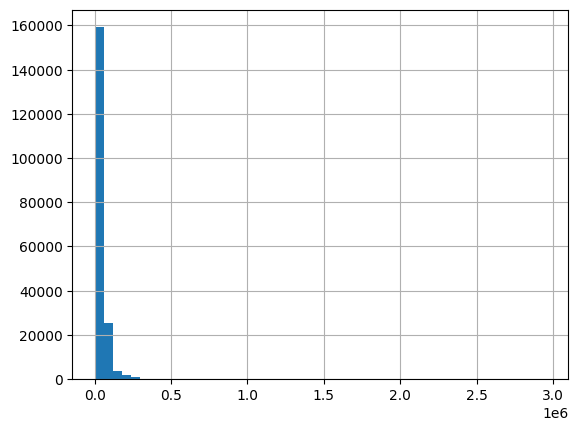

: 

In [ ]:
y.describe()
y.hist(bins=50)
np.percentile(y, [90, 95, 99])
